## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load the Dataset

In [2]:
import pandas as pd
from google.colab import files

# Upload file
uploaded = files.upload()

# Read into DataFrame
df = pd.read_csv("Titanic-Dataset.csv")
df.head()


Saving Titanic-Dataset.csv to Titanic-Dataset.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Basic Information About Dataset

In [3]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

# 4. Data Cleaning


In [5]:
#Check Null Values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# Handle Null Values
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Fill missing Embarked values with mode

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column because it contains many null values

df.drop(columns=['Cabin'], inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_475/3576426605.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_475/3576426605.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

# 5. Duplicate Removal

In [7]:
print(df.duplicated().sum())

# Remove duplicates

df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

0
0


# 6. Basic Statistical Analysis

In [8]:
print("Average Age:", df['Age'].mean())
print("Maximum Fare:", df['Fare'].max())
print("Minimum Fare:", df['Fare'].min())
print("Total Passengers:", len(df))

Average Age: 29.69911764705882
Maximum Fare: 512.3292
Minimum Fare: 0.0
Total Passengers: 891


# 7. Generate Insights

In [9]:

#Insight 1: Survival Count
print(df['Survived'].value_counts())
#Observation - More passengers died compared to those who survived.

#Insight 2: Gender Distribution
print(df['Sex'].value_counts())
#Observation -Male passengers were higher than female passengers.

#Insight 3: Passenger Class Distribution
print(df['Pclass'].value_counts())
#Observation -Most passengers traveled in 3rd class.

Survived
0    549
1    342
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


# 8. Data Visualization

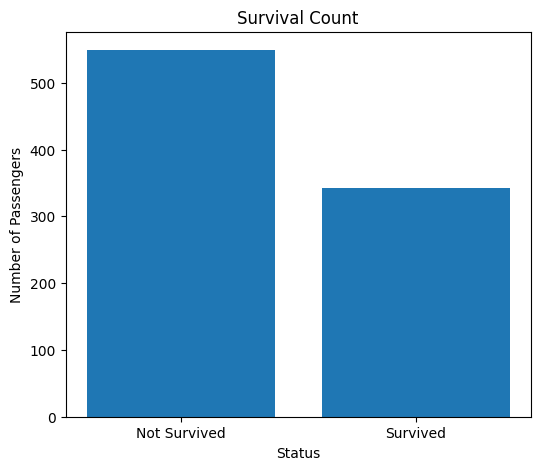

In [10]:

#A. Bar Chart
#Survival Count Bar Chart
survival_count = df['Survived'].value_counts()


plt.figure(figsize=(6,5))
plt.bar(['Not Survived', 'Survived'], survival_count)
plt.title('Survival Count')
plt.xlabel('Status')
plt.ylabel('Number of Passengers')
plt.show()
#Output Explanation - The bar chart compares survived and non-survived passengers.

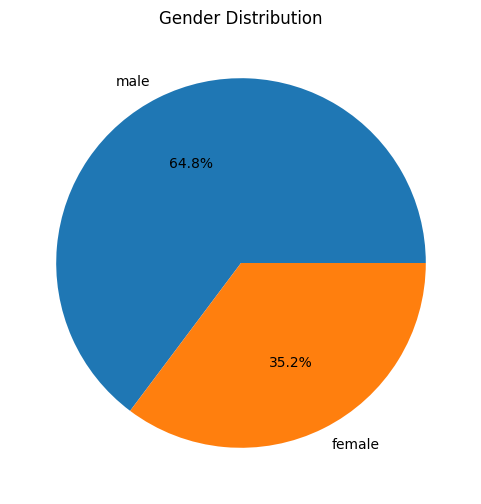

In [11]:
#B. Pie Chart - Gender Distribution Pie Chart
gender_count = df['Sex'].value_counts()


plt.figure(figsize=(6,6))
plt.pie(gender_count, labels=gender_count.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()
#Output Explanation - The pie chart shows percentage distribution of male and female passengers.

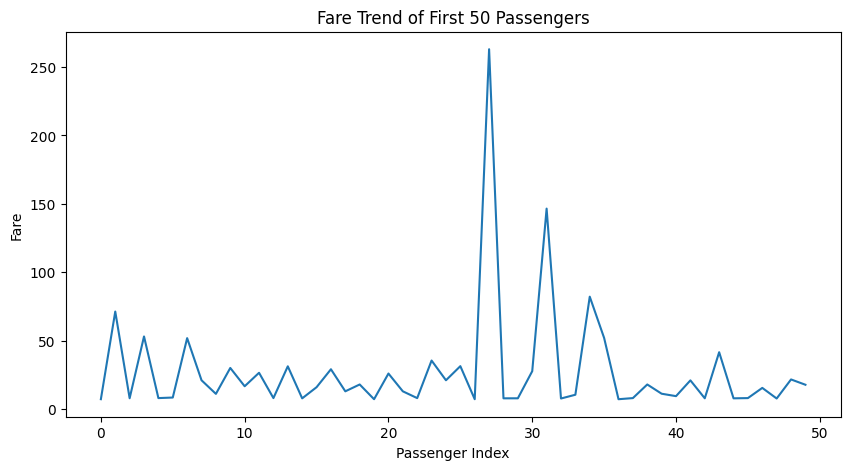

In [13]:
#C. Line Graph - Passenger Fare Trend
plt.figure(figsize=(10,5))
plt.plot(df['Fare'].head(50))
plt.title('Fare Trend of First 50 Passengers')
plt.xlabel('Passenger Index')
plt.ylabel('Fare')
plt.show()
#Output Explanation - The line graph shows fare variation among passengers.